In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from datetime import datetime
import re
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

data = pd.read_csv('coffeeQuality.csv',index_col = 0)

In [2]:
data.head()

,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,Region,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,NaN,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,oromia,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


In [3]:
data = data.drop_duplicates()

In [4]:
data

,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,Region,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,NaN,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,oromia,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1334,Robusta,luis robles,Ecuador,robustasa,Lavado 1,our own lab,NaN,robustasa,NaN,"san juan, playas",...,Blue-Green,1,"January 18th, 2017",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,NaN,NaN,NaN
1335,Robusta,luis robles,Ecuador,robustasa,Lavado 3,own laboratory,NaN,robustasa,40,"san juan, playas",...,Blue-Green,0,"January 18th, 2017",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,40.0,40.0,40.0
1336,Robusta,james moore,United States,fazenda cazengo,NaN,cafe cazengo,NaN,global opportunity fund,795 meters,"kwanza norte province, angola",...,NaN,6,"December 23rd, 2015",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,795.0,795.0,795.0
1337,Robusta,cafe politico,India,NaN,NaN,NaN,14-1118-2014-0087,cafe politico,NaN,NaN,...,Green,1,"August 25th, 2015",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,NaN,NaN,NaN


In [5]:
df = data.copy()

In [6]:
df.columns

Index(['Species', 'Owner', 'Country.of.Origin', 'Farm.Name', 'Lot.Number',
       'Mill', 'ICO.Number', 'Company', 'Altitude', 'Region', 'Producer',
       'Number.of.Bags', 'Bag.Weight', 'In.Country.Partner', 'Harvest.Year',
       'Grading.Date', 'Owner.1', 'Variety', 'Processing.Method', 'Aroma',
       'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity',
       'Clean.Cup', 'Sweetness', 'Cupper.Points', 'Total.Cup.Points',
       'Moisture', 'Category.One.Defects', 'Quakers', 'Color',
       'Category.Two.Defects', 'Expiration', 'Certification.Body',
       'Certification.Address', 'Certification.Contact', 'unit_of_measurement',
       'altitude_low_meters', 'altitude_high_meters', 'altitude_mean_meters'],
      dtype='object')

In [7]:
df.columns = df.columns.str.replace('.', '_', regex=False)

In [8]:
df.columns

Index(['Species', 'Owner', 'Country_of_Origin', 'Farm_Name', 'Lot_Number',
       'Mill', 'ICO_Number', 'Company', 'Altitude', 'Region', 'Producer',
       'Number_of_Bags', 'Bag_Weight', 'In_Country_Partner', 'Harvest_Year',
       'Grading_Date', 'Owner_1', 'Variety', 'Processing_Method', 'Aroma',
       'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity',
       'Clean_Cup', 'Sweetness', 'Cupper_Points', 'Total_Cup_Points',
       'Moisture', 'Category_One_Defects', 'Quakers', 'Color',
       'Category_Two_Defects', 'Expiration', 'Certification_Body',
       'Certification_Address', 'Certification_Contact', 'unit_of_measurement',
       'altitude_low_meters', 'altitude_high_meters', 'altitude_mean_meters'],
      dtype='object')

In [9]:
df.unit_of_measurement.value_counts()

unit_of_measurement
m     1157
ft     182
Name: count, dtype: int64

In [10]:
df.head()

,Species,Owner,Country_of_Origin,Farm_Name,Lot_Number,Mill,ICO_Number,Company,Altitude,Region,...,Color,Category_Two_Defects,Expiration,Certification_Body,Certification_Address,Certification_Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,NaN,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,oromia,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


In [11]:
df['unit_of_measurement'].value_counts()

unit_of_measurement
m     1157
ft     182
Name: count, dtype: int64

In [12]:
pd.set_option('display.max_columns',50)
df.head(5)

df.drop(columns=['Certification_Address','Certification_Contact','unit_of_measurement'],inplace=True)

In [13]:
df['Expiration'].head()

0     April 3rd, 2016
1     April 3rd, 2016
2      May 31st, 2011
3    March 25th, 2016
4     April 3rd, 2016
Name: Expiration, dtype: object

In [14]:
df['Species'] = df['Species'].astype(str)
df['Country_of_Origin'] = df['Country_of_Origin'].astype(str)
df['Farm_Name'] = df['Farm_Name'].astype(str)
df['Lot_Number'] = df['Lot_Number'].astype(str)
df['Mill'] = df['Mill'].astype(str)
df['Company'] = df['Company'].astype(str)
df['Expiration'] = df['Expiration'].apply(lambda x: pd.to_datetime(re.sub(r'(\d+)(st|nd|rd|th)', r'\1', x)))

In [15]:
df['Expiration'].head()

0   2016-04-03
1   2016-04-03
2   2011-05-31
3   2016-03-25
4   2016-04-03
Name: Expiration, dtype: datetime64[ns]

In [16]:
df.shape

(1339, 40)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1339 entries, 0 to 1338
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Species               1339 non-null   object        
 1   Owner                 1332 non-null   object        
 2   Country_of_Origin     1339 non-null   object        
 3   Farm_Name             1339 non-null   object        
 4   Lot_Number            1339 non-null   object        
 5   Mill                  1339 non-null   object        
 6   ICO_Number            1180 non-null   object        
 7   Company               1339 non-null   object        
 8   Altitude              1113 non-null   object        
 9   Region                1280 non-null   object        
 10  Producer              1107 non-null   object        
 11  Number_of_Bags        1338 non-null   float64       
 12  Bag_Weight            1339 non-null   object        
 13  In_Country_Partner    1

In [18]:
df.describe()

,Number_of_Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean_Cup,Sweetness,Cupper_Points,Total_Cup_Points,Moisture,Category_One_Defects,Quakers,Category_Two_Defects,Expiration,altitude_low_meters,altitude_high_meters,altitude_mean_meters
count,1338.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1338.000000,1339.000000,1339,1109.000000,1109.000000,1109.000000
mean,159.085202,7.770187,7.520426,7.401083,7.535706,7.517498,7.518013,9.834877,9.835108,9.856692,7.503376,82.089851,0.088379,0.479462,0.173393,3.556385,2015-03-22 19:15:00.672143360,1750.713315,1799.347775,1775.030545
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2011-04-09 00:00:00,1.000000,1.000000,1.000000
25%,14.000000,7.420000,7.330000,7.250000,7.330000,7.330000,7.330000,10.000000,10.000000,10.000000,7.250000,81.080000,0.090000,0.000000,0.000000,0.000000,2013-08-17 00:00:00,1100.000000,1100.000000,1100.000000
50%,175.000000,7.580000,7.580000,7.420000,7.580000,7.500000,7.500000,10.000000,10.000000,10.000000,7.500000,82.500000,0.110000,0.000000,0.000000,2.000000,2015-04-03 00:00:00,1310.640000,1350.000000,1310.640000
75%,275.000000,7.750000,7.750000,7.580000,7.750000,7.670000,7.750000,10.000000,10.000000,10.000000,7.750000,83.670000,0.120000,0.000000,0.000000,4.000000,2016-07-16 00:00:00,1600.000000,1650.000000,1600.000000
max,3200.000000,200.000000,8.830000,8.670000,8.750000,8.580000,8.750000,10.000000,10.000000,10.000000,10.000000,90.580000,0.280000,63.000000,11.000000,55.000000,2019-01-19 00:00:00,190164.000000,190164.000000,190164.000000
std,173.698167,5.534440,0.398442,0.404463,0.379827,0.370064,0.408943,0.554591,0.763946,0.616102,0.473464,3.500575,0.048287,2.549683,0.832121,5.312541,NaN,8669.440545,8668.805771,8668.626080


In [19]:
# Variables in the dataset
set(df)

{'Acidity',
 'Aftertaste',
 'Altitude',
 'Aroma',
 'Bag_Weight',
 'Balance',
 'Body',
 'Category_One_Defects',
 'Category_Two_Defects',
 'Certification_Body',
 'Clean_Cup',
 'Color',
 'Company',
 'Country_of_Origin',
 'Cupper_Points',
 'Expiration',
 'Farm_Name',
 'Flavor',
 'Grading_Date',
 'Harvest_Year',
 'ICO_Number',
 'In_Country_Partner',
 'Lot_Number',
 'Mill',
 'Moisture',
 'Number_of_Bags',
 'Owner',
 'Owner_1',
 'Processing_Method',
 'Producer',
 'Quakers',
 'Region',
 'Species',
 'Sweetness',
 'Total_Cup_Points',
 'Uniformity',
 'Variety',
 'altitude_high_meters',
 'altitude_low_meters',
 'altitude_mean_meters'}

In [20]:
df.isnull().sum()

Species                   0
Owner                     7
Country_of_Origin         0
Farm_Name                 0
Lot_Number                0
Mill                      0
ICO_Number              159
Company                   0
Altitude                226
Region                   59
Producer                232
Number_of_Bags            1
Bag_Weight                0
In_Country_Partner        0
Harvest_Year             47
Grading_Date              0
Owner_1                   7
Variety                 226
Processing_Method       170
Aroma                     0
Flavor                    0
Aftertaste                0
Acidity                   0
Body                      0
Balance                   0
Uniformity                0
Clean_Cup                 0
Sweetness                 0
Cupper_Points             0
Total_Cup_Points          0
Moisture                  0
Category_One_Defects      0
Quakers                   1
Color                   270
Category_Two_Defects      0
Expiration          

In [21]:
df.drop(columns = 'ICO_Number',inplace=True)

In [22]:
# 4. Check Missing Values
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Color                   270
Producer                232
altitude_low_meters     230
altitude_high_meters    230
altitude_mean_meters    230
Altitude                226
Variety                 226
Processing_Method       170
Region                   59
Harvest_Year             47
Owner                     7
Owner_1                   7
Number_of_Bags            1
Quakers                   1
dtype: int64

In [23]:
# 5. Drop Duplicates
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (1339, 39)


In [24]:

df['Color'] = df['Color'].fillna(df['Color'].mode()[0])
df['Producer'] = df['Producer'].fillna(df['Producer'].mode()[0])
df['altitude_low_meters'] = df['altitude_low_meters'].fillna(df['altitude_low_meters'].median())
df['altitude_high_meters'] = df['altitude_high_meters'].fillna(df['altitude_high_meters'].mode()[0])
df['altitude_mean_meters'] = df['altitude_mean_meters'].fillna(df['Color'].mode()[0])
df['Altitude'] = df['Altitude'].fillna(df['Altitude'].mode()[0])
df['Variety'] = df['Variety'].fillna(df['Variety'].mode()[0])
df['Processing_Method'] = df['Processing_Method'].fillna(df['Processing_Method'].mode()[0])
df['Harvest_Year'] = df['Harvest_Year'].fillna(df['Harvest_Year'].mode()[0])
df['Region'] = df['Region'].fillna(df['Region'].mode()[0])
df['Owner'] = df['Owner'].fillna(df['Owner'].mode()[0])
df['Owner_1'] = df['Owner_1'].fillna(df['Owner_1'].mode()[0])
df['Number_of_Bags'] = df['Number_of_Bags'].fillna(df['Number_of_Bags'].mode()[0])
df['Quakers'] = df['Quakers'].fillna(df['Quakers'].mode()[0])


In [27]:
df['Altitude'].value_counts()

Altitude
1100             269
1200              42
1300              32
1400              32
4300              31
                ... 
1473               1
1600 - 1800 m      1
4500 pies          1
900-1100           1
795 meters         1
Name: count, Length: 396, dtype: int64

In [30]:
def extract_first_number(x):
    try:
        match = re.search(r"^\s*(\d+(?:\.\d+)?)", str(x))
        if match:
            return float(match.group(1))
        else:
            return np.nan
    except:
        return np.nan


median_aroma = df[df['Aroma'] <= 10]['Aroma'].median()
df['Aroma'] = df['Aroma'].apply(lambda x: median_aroma if x > 10 else x)
df['Altitude_Clean'] = df['Altitude'].apply(extract_first_number)

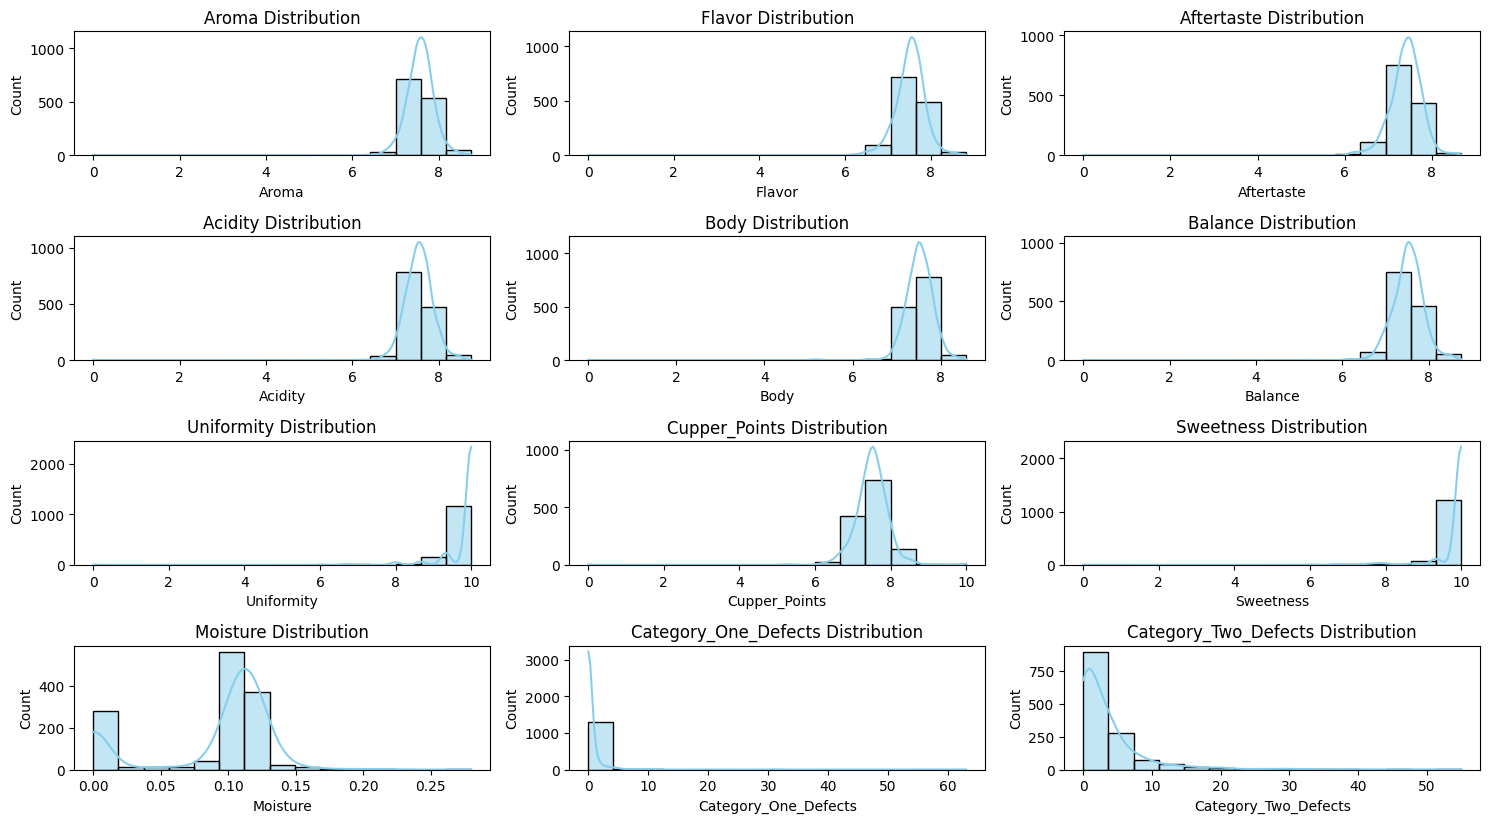

In [31]:
# 6. Univariate Analysis - Numerical Features
quality_cols = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body',
                'Balance', 'Uniformity', 'Cupper_Points', 'Sweetness', 
                'Moisture', 'Category_One_Defects','Category_Two_Defects']
    
plt.figure(figsize=(15, 12))
for i, col in enumerate(quality_cols):
    plt.subplot(6, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=15, color='skyblue', palette='viridis')
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

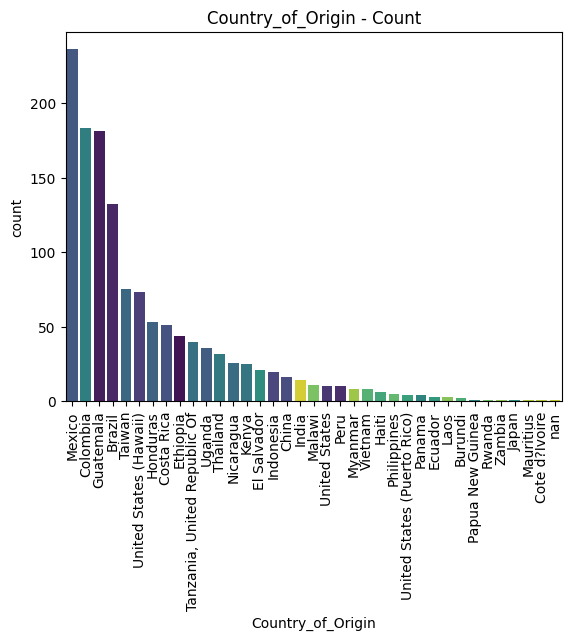

In [32]:
sns.countplot(data=df, x='Country_of_Origin', hue='Country_of_Origin', order=df['Country_of_Origin'].value_counts().index,  palette='viridis', legend=False)
plt.title(f'Country_of_Origin - Count')
plt.xticks(rotation=90)
plt.show()

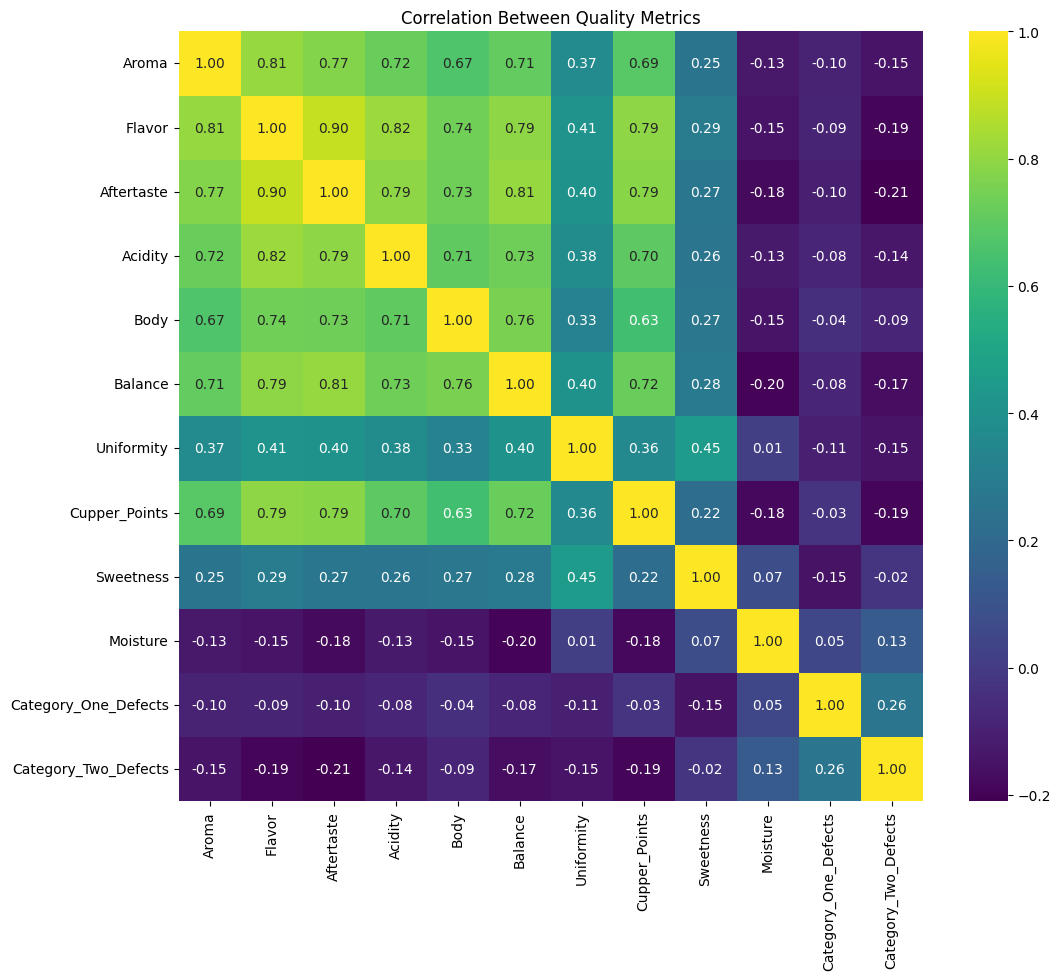

In [33]:
# 8. Bivariate Analysis - Correlation
plt.figure(figsize=(12, 10))
corr = df[quality_cols].corr()
sns.heatmap(corr, annot=True, cmap='viridis', fmt=".2f")
plt.title("Correlation Between Quality Metrics")
plt.show()

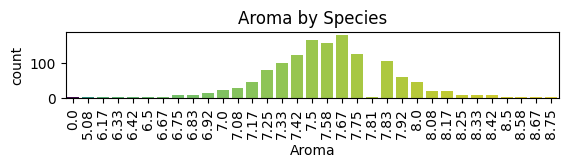

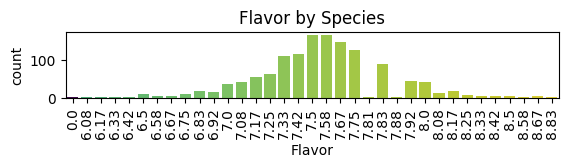

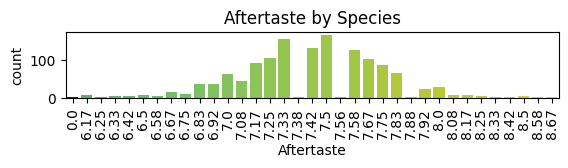

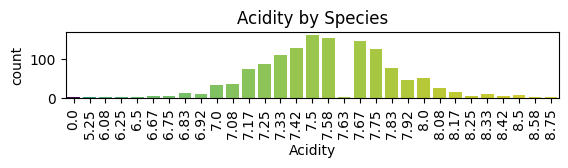

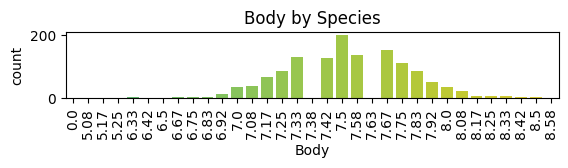

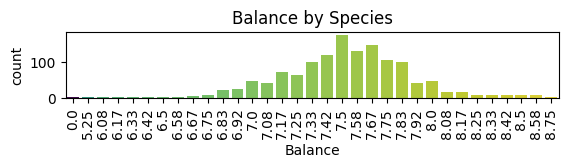

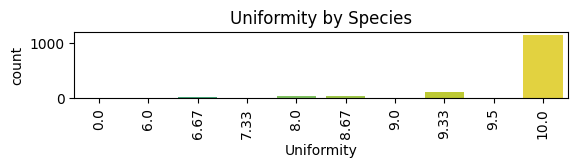

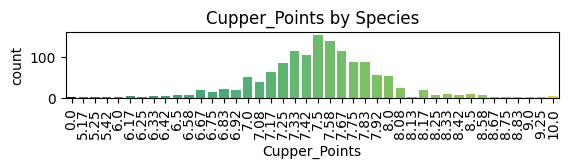

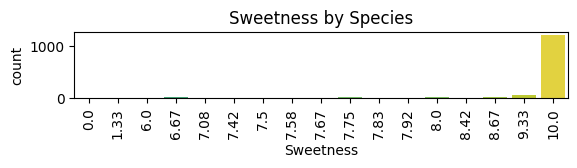

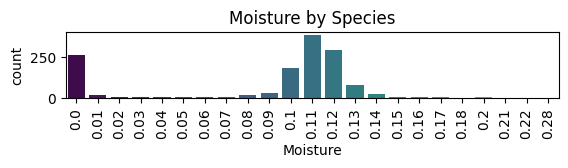

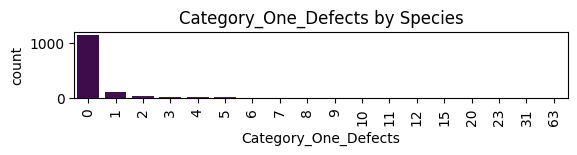

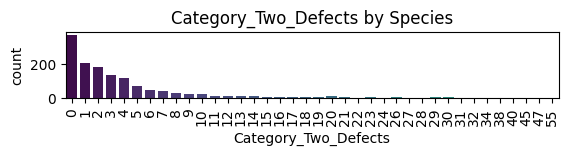

In [34]:
# 9. Boxplots - Quality Measures by Species
for col in quality_cols:
    plt.figure(figsize=(14, 6))
    plt.subplot(6, 2, i + 1)
    plt.xticks(rotation=90)
    sns.countplot(data=df, x=col, hue=col,  palette='viridis', legend=False)
    plt.title(f'{col} by Species')
    plt.show()

### Aroma
It is distinctive, typically pleasant smell.

### Flavor
The overall perception of taste and aroma, encompassing the combined sensations of taste, smell, and mouthfeel.

### Acidity
The bright, lively, and sometimes fruity notes that contribute to a vibrant and complex. Not the pH.

### Aftertaste

It refers to the lingering taste sensation in the mouth after swallowing a sip.

### Sweetness 
It refers to the pleasant, natural sugar-like quality in the flavor of the coffee.

### Uniformity
The consistency in bean size, roast development, and particle size during grinding

### Balance

Balanced → flavors complement each other

Unbalanced → too bitter or sour



### Body 
It is the sensation of heaviness, thickness, or viscosity of the coffee in your mouth. It's the difference between drinking something light like water and something thick like milk. 

### Moisture
The amount of water in the green coffee beans.

### Category Defect 1 : 
Full black or sour bean, pod/cherry, and large or medium sticks or stones.
### Category Defect 2: 
Parchment, hull/husk, broken/chipped, insect damage, partial black or sour, shell, small sticks or stones, water damage.

### Cupper Points 
It is the overall score given to a coffee sample based on the sensory evaluation of its attributes, including fragrance/aroma, acidity, flavor, body, aftertaste, sweetness, uniformity, and cleanliness, and taking into account any defect.

In [35]:
df['altitude_mean_meters'].value_counts()

altitude_mean_meters
Green      230
1200.0      67
1100.0      53
1400.0      52
1300.0      50
          ... 
1261.0       1
2100.0       1
1280.16      1
1227.0       1
795.0        1
Name: count, Length: 212, dtype: int64

In [36]:
non_numeric_rows = df[~df['altitude_mean_meters'].astype(str).str.replace('.', '', 1).str.isnumeric()]
print(non_numeric_rows)

      Species                        Owner       Country_of_Origin  Farm_Name  \
5     Arabica                    ji-ae ahn                  Brazil        nan   
6     Arabica                hugo valdivia                    Peru        nan   
17    Arabica  ethiopia commodity exchange                Ethiopia        nan   
24    Arabica                    ji-ae ahn                Ethiopia        nan   
26    Arabica  ethiopia commodity exchange                Ethiopia        nan   
...       ...                          ...                     ...        ...   
1296  Arabica              eileen koyanagi  United States (Hawaii)        nan   
1302  Arabica       volcafe ltda. - brasil                  Brazil        nan   
1334  Robusta                  luis robles                 Ecuador  robustasa   
1337  Robusta                cafe politico                   India        nan   
1338  Robusta                cafe politico                 Vietnam        nan   

             Lot_Number    

In [37]:
# Step 1: Identify rows where 'altitude_mean_meters' is 'Green'
mask = df['altitude_mean_meters'] == 'Green'

# Step 2: Set 'color' to 'Green' in those rows
df.loc[mask, 'Color'] = 'Green'

# Step 3: Replace 'Green' in altitude with NaN
df.loc[mask, 'altitude_mean_meters'] = None

In [38]:
df['Color'] = df['Color'].replace({
    'Bluish-Green': 'Bluish/Blue-Green',
    'Blue-Green': 'Bluish/Blue-Green'
})

data = df['Color'].value_counts().reset_index()
data

,Color,count
0,Green,1185
1,Bluish/Blue-Green,154


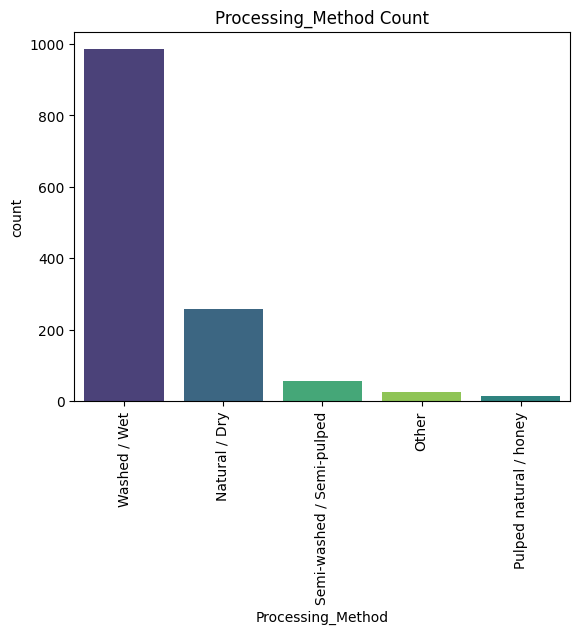

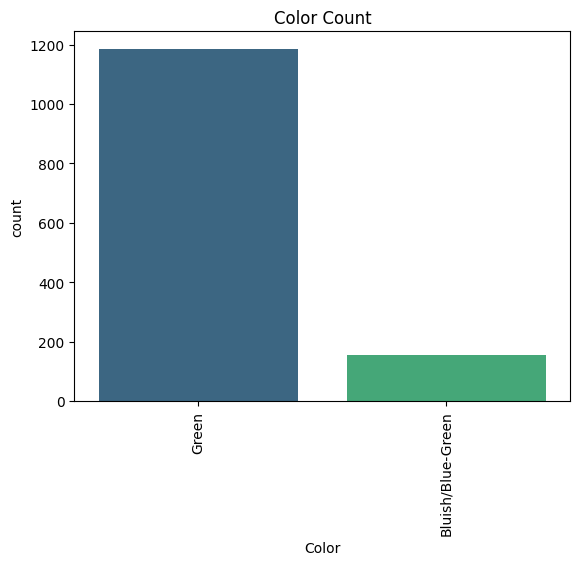

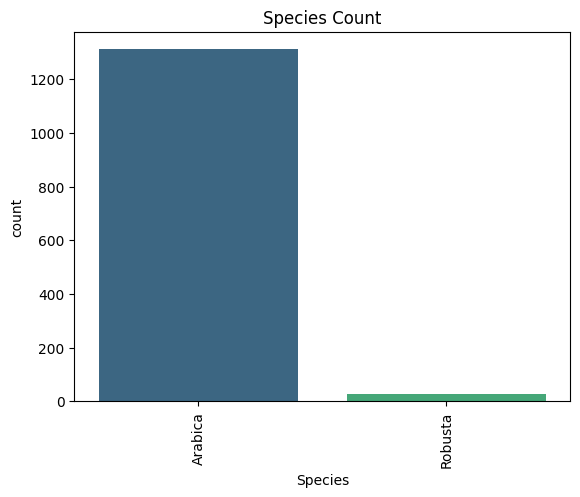

In [39]:
# 7. Univariate Analysis - Categorical Features
categorical_cols = ['Processing_Method', 'Color', 'Species']

for col in categorical_cols:
    sns.countplot(data=df, x=col, hue=col, order=df[col].value_counts().index,  palette='viridis', legend=False)
    plt.title(f'{col} Count')
    plt.xticks(rotation=90)
    plt.show()

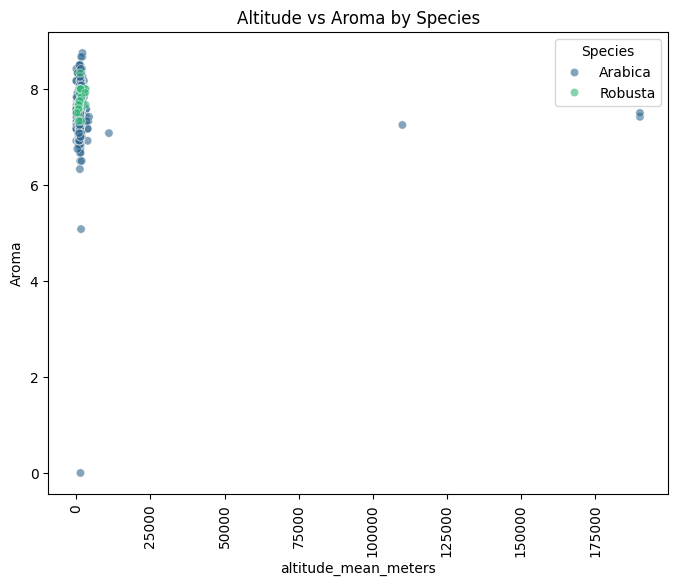

In [40]:
# 10. Altitude vs Quality
plt.figure(figsize=(8, 6))
plt.xticks(rotation=90)
sns.scatterplot(data=df, x='altitude_mean_meters', y='Aroma', palette='viridis', hue='Species', alpha=0.6)
plt.title('Altitude vs Aroma by Species')
plt.show()

In [41]:
df['Altitude'].value_counts()

Altitude
1100             269
1200              42
1300              32
1400              32
4300              31
                ... 
1473               1
1600 - 1800 m      1
4500 pies          1
900-1100           1
795 meters         1
Name: count, Length: 396, dtype: int64

In [42]:
df['Altitude_Clean'] = df['Altitude'].astype(str)
df['Altitude_Clean'] = df['Altitude_Clean'].str.extract(r'(\d{3,5})')  # extract 3-5 digit number
df['Altitude_Clean'] = df['Altitude_Clean'].astype(float)

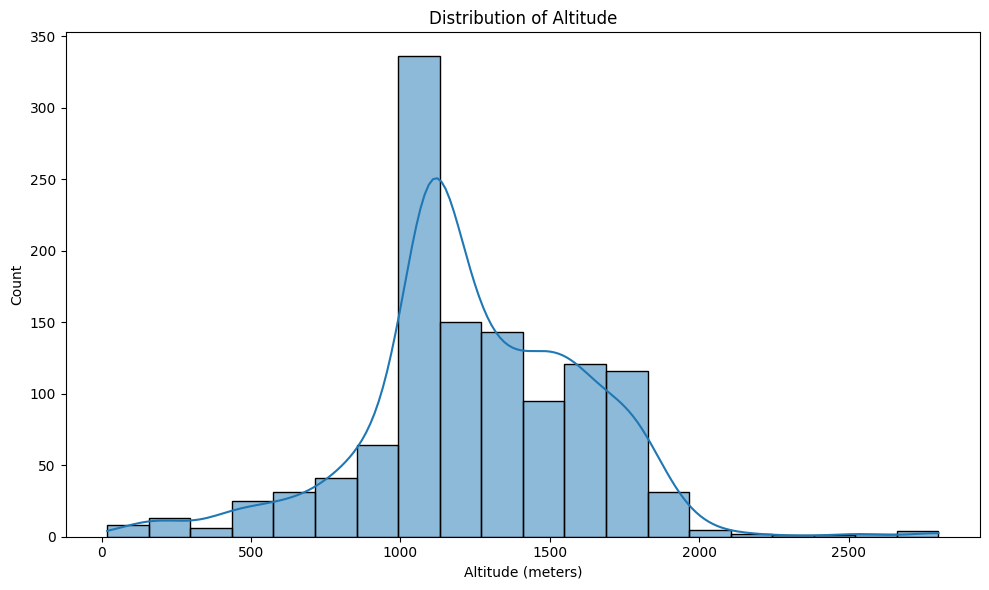

In [43]:
plt.figure(figsize=(10, 6))
mask = df[df['Altitude_Clean'] < 3000]

sns.histplot(mask['Altitude_Clean'], bins=20, kde=True, palette='viridis')
plt.title('Distribution of Altitude')
plt.xlabel('Altitude (meters)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [44]:
df.drop(columns = ['Altitude','altitude_low_meters','altitude_high_meters','altitude_mean_meters'],inplace=True)

In [45]:
df['Category_Two_Defects'].value_counts()

Category_Two_Defects
0     373
1     207
2     182
3     134
4     118
5      73
6      44
7      41
8      29
9      23
10     21
12     13
13      9
14      9
20      8
11      8
17      7
16      6
15      6
19      3
26      3
21      2
29      2
18      2
23      2
30      2
47      1
24      1
27      1
28      1
31      1
40      1
38      1
45      1
34      1
22      1
32      1
55      1
Name: count, dtype: int64

In [46]:
df.head()

,Species,Owner,Country_of_Origin,Farm_Name,Lot_Number,Mill,Company,Region,Producer,Number_of_Bags,Bag_Weight,In_Country_Partner,Harvest_Year,Grading_Date,Owner_1,Variety,Processing_Method,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean_Cup,Sweetness,Cupper_Points,Total_Cup_Points,Moisture,Category_One_Defects,Quakers,Color,Category_Two_Defects,Expiration,Certification_Body,Altitude_Clean
0,Arabica,metad plc,Ethiopia,metad plc,nan,metad plc,metad agricultural developmet plc,guji-hambela,METAD PLC,300.0,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Caturra,Washed / Wet,8.67,8.83,8.67,8.75,8.50,8.42,10.0,10.0,10.0,8.75,90.58,0.12,0,0.0,Green,0,2016-04-03,METAD Agricultural Development plc,1950.0
1,Arabica,metad plc,Ethiopia,metad plc,nan,metad plc,metad agricultural developmet plc,guji-hambela,METAD PLC,300.0,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Other,Washed / Wet,8.75,8.67,8.50,8.58,8.42,8.42,10.0,10.0,10.0,8.58,89.92,0.12,0,0.0,Green,1,2016-04-03,METAD Agricultural Development plc,1950.0
2,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",nan,nan,nan,huila,La Plata,5.0,1,Specialty Coffee Association,2012,"May 31st, 2010",Grounds for Health Admin,Bourbon,Washed / Wet,8.42,8.50,8.42,8.42,8.33,8.42,10.0,10.0,10.0,9.25,89.75,0.00,0,0.0,Green,0,2011-05-31,Specialty Coffee Association,1600.0
3,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,nan,wolensu,yidnekachew debessa coffee plantation,oromia,Yidnekachew Dabessa Coffee Plantation,320.0,60 kg,METAD Agricultural Development plc,2014,"March 26th, 2015",Yidnekachew Dabessa,Caturra,Natural / Dry,8.17,8.58,8.42,8.42,8.50,8.25,10.0,10.0,10.0,8.67,89.00,0.11,0,0.0,Green,2,2016-03-25,METAD Agricultural Development plc,1800.0
4,Arabica,metad plc,Ethiopia,metad plc,nan,metad plc,metad agricultural developmet plc,guji-hambela,METAD PLC,300.0,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Other,Washed / Wet,8.25,8.50,8.25,8.50,8.42,8.33,10.0,10.0,10.0,8.58,88.83,0.12,0,0.0,Green,2,2016-04-03,METAD Agricultural Development plc,1950.0


In [47]:
def convert_bag_weight(val):
    val = str(val).lower().strip()

    # Case 1: Contains both kg and lbs (ambiguous)
    if 'kg' in val and 'lbs' in val:
        return np.nan  # or choose to drop

    # Case 2: lbs to kg
    if 'lbs' in val:
        match = re.match(r'(\d+)', val)
        if match:
            lbs = float(match.group(1))
            return round(lbs * 0.453592, 2)  # convert to kg

    # Case 3: kg
    elif 'kg' in val:
        match = re.match(r'(\d+)', val)
        if match:
            return float(match.group(1))

    # Case 4: only digits (no unit)
    elif val.isdigit():
        return float(val)  # assume kg

    return np.nan  # fallback

# Apply cleaning
df['Weight_Kg_Clean'] = df['Bag_Weight'].apply(convert_bag_weight)

In [48]:
df['Processing_Method_Clean'] = (
    df['Processing_Method']
    .replace({
        'Washed / Wet': 'Washed',
        'Natural / Dry': 'Dry',
        'Semi-washed / Semi-pulped': 'Semi-washed',
        'Pulped natural / honey': 'Honey Process',
    })
)

In [49]:
df['Processing_Method_Clean'].value_counts()

Processing_Method_Clean
Washed           985
Dry              258
Semi-washed       56
Other             26
Honey Process     14
Name: count, dtype: int64

In [50]:
data = df['Processing_Method_Clean'].value_counts()

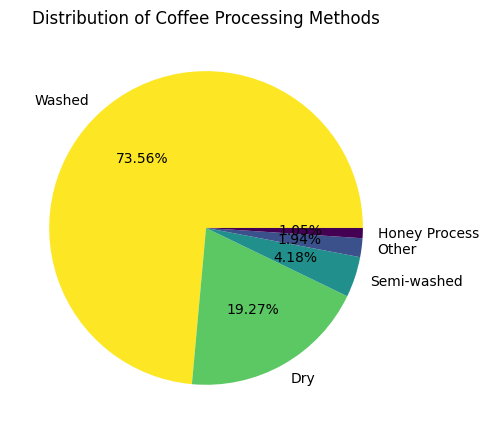

In [51]:
import matplotlib.cm as cm
plt.figure(figsize=(5, 6))

colors = cm.viridis_r(np.linspace(0, 1, len(data.index)))
plt.pie(
    data.values,
    labels=data.index,
    autopct='%1.2f%%',
    colors=colors
    )
plt.title('Distribution of Coffee Processing Methods')
plt.tight_layout()
plt.show()

In [52]:
df.drop(columns=['Processing_Method'],inplace=True)

In [53]:
df.head()

,Species,Owner,Country_of_Origin,Farm_Name,Lot_Number,Mill,Company,Region,Producer,Number_of_Bags,Bag_Weight,In_Country_Partner,Harvest_Year,Grading_Date,Owner_1,Variety,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean_Cup,Sweetness,Cupper_Points,Total_Cup_Points,Moisture,Category_One_Defects,Quakers,Color,Category_Two_Defects,Expiration,Certification_Body,Altitude_Clean,Weight_Kg_Clean,Processing_Method_Clean
0,Arabica,metad plc,Ethiopia,metad plc,nan,metad plc,metad agricultural developmet plc,guji-hambela,METAD PLC,300.0,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Caturra,8.67,8.83,8.67,8.75,8.50,8.42,10.0,10.0,10.0,8.75,90.58,0.12,0,0.0,Green,0,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed
1,Arabica,metad plc,Ethiopia,metad plc,nan,metad plc,metad agricultural developmet plc,guji-hambela,METAD PLC,300.0,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Other,8.75,8.67,8.50,8.58,8.42,8.42,10.0,10.0,10.0,8.58,89.92,0.12,0,0.0,Green,1,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed
2,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",nan,nan,nan,huila,La Plata,5.0,1,Specialty Coffee Association,2012,"May 31st, 2010",Grounds for Health Admin,Bourbon,8.42,8.50,8.42,8.42,8.33,8.42,10.0,10.0,10.0,9.25,89.75,0.00,0,0.0,Green,0,2011-05-31,Specialty Coffee Association,1600.0,1.0,Washed
3,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,nan,wolensu,yidnekachew debessa coffee plantation,oromia,Yidnekachew Dabessa Coffee Plantation,320.0,60 kg,METAD Agricultural Development plc,2014,"March 26th, 2015",Yidnekachew Dabessa,Caturra,8.17,8.58,8.42,8.42,8.50,8.25,10.0,10.0,10.0,8.67,89.00,0.11,0,0.0,Green,2,2016-03-25,METAD Agricultural Development plc,1800.0,60.0,Dry
4,Arabica,metad plc,Ethiopia,metad plc,nan,metad plc,metad agricultural developmet plc,guji-hambela,METAD PLC,300.0,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Other,8.25,8.50,8.25,8.50,8.42,8.33,10.0,10.0,10.0,8.58,88.83,0.12,0,0.0,Green,2,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed


In [54]:
data = df['Certification_Body'].value_counts()

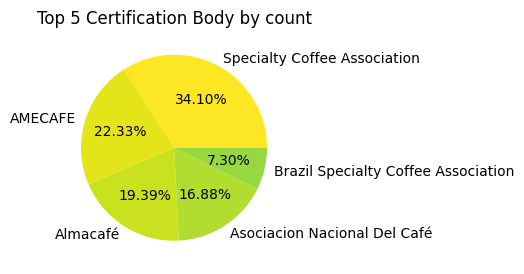

In [55]:
plt.figure(figsize=(3, 6))

colors = cm.viridis_r(np.linspace(0, 1, len(data.index)))
plt.pie(
    data.values[:5],
    labels=data.index[:5],
    autopct='%1.2f%%',
    colors=colors
    )
plt.title('Top 5 Certification Body by count')
plt.tight_layout()
plt.show()

In [56]:
data = df['Quakers'].value_counts().reset_index()
data

,Quakers,count
0,0.0,1245
1,1.0,39
2,2.0,30
3,4.0,5
4,5.0,5
5,3.0,5
6,6.0,4
7,7.0,3
8,11.0,1
9,9.0,1


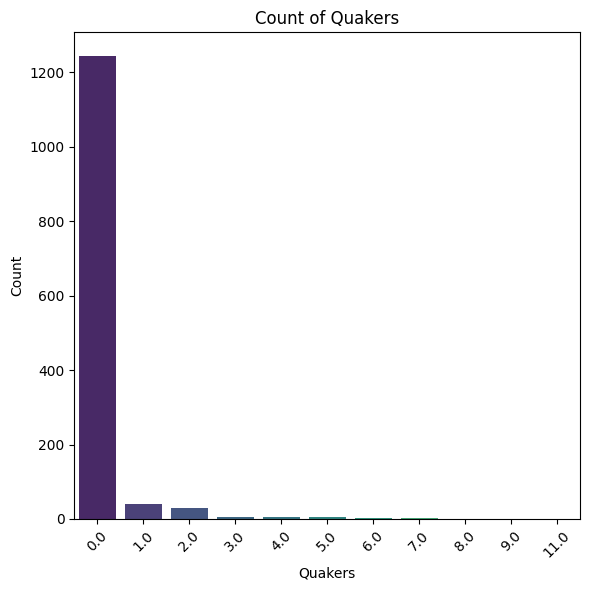

In [57]:
plt.figure(figsize=(6, 6))
sns.barplot(data=data, x='Quakers',y='count',  palette='viridis')
plt.title('Count of Quakers')
plt.xlabel('Quakers')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate if labels are long
plt.tight_layout()
plt.show()

In [58]:
data = df['Color'].value_counts().reset_index()
data

,Color,count
0,Green,1185
1,Bluish/Blue-Green,154


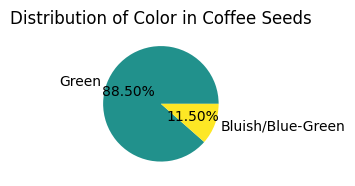

In [59]:
plt.figure(figsize=(3, 6))

colors = cm.viridis(np.linspace(0.5, 1, len(data.index)))
plt.pie(
    data['count'],
    labels=data['Color'],
    autopct='%1.2f%%',
    colors=colors
    )
plt.title('Distribution of Color in Coffee Seeds')
plt.tight_layout()
plt.show()

In [60]:
df.head()
df.drop(columns='Lot_Number',inplace=True)

In [61]:
df['Grading_Date'] = df['Grading_Date'].apply(lambda x: pd.to_datetime(re.sub(r'(\d+)(st|nd|rd|th)', r'\1', x)))

In [62]:
df['Grading_Date']

0      2015-04-04
1      2015-04-04
2      2010-05-31
3      2015-03-26
4      2015-04-04
          ...    
1334   2016-01-19
1335   2016-01-19
1336   2014-12-23
1337   2014-08-25
1338   2014-08-25
Name: Grading_Date, Length: 1339, dtype: datetime64[ns]

In [63]:
df.drop(columns='Owner_1',inplace=True)

In [64]:
df['Owner'] = df['Owner'].apply(lambda x:x.title())

In [65]:
df.head()

,Species,Owner,Country_of_Origin,Farm_Name,Mill,Company,Region,Producer,Number_of_Bags,Bag_Weight,In_Country_Partner,Harvest_Year,Grading_Date,Variety,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean_Cup,Sweetness,Cupper_Points,Total_Cup_Points,Moisture,Category_One_Defects,Quakers,Color,Category_Two_Defects,Expiration,Certification_Body,Altitude_Clean,Weight_Kg_Clean,Processing_Method_Clean
0,Arabica,Metad Plc,Ethiopia,metad plc,metad plc,metad agricultural developmet plc,guji-hambela,METAD PLC,300.0,60 kg,METAD Agricultural Development plc,2014,2015-04-04,Caturra,8.67,8.83,8.67,8.75,8.50,8.42,10.0,10.0,10.0,8.75,90.58,0.12,0,0.0,Green,0,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed
1,Arabica,Metad Plc,Ethiopia,metad plc,metad plc,metad agricultural developmet plc,guji-hambela,METAD PLC,300.0,60 kg,METAD Agricultural Development plc,2014,2015-04-04,Other,8.75,8.67,8.50,8.58,8.42,8.42,10.0,10.0,10.0,8.58,89.92,0.12,0,0.0,Green,1,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed
2,Arabica,Grounds For Health Admin,Guatemala,"san marcos barrancas ""san cristobal cuch",nan,nan,huila,La Plata,5.0,1,Specialty Coffee Association,2012,2010-05-31,Bourbon,8.42,8.50,8.42,8.42,8.33,8.42,10.0,10.0,10.0,9.25,89.75,0.00,0,0.0,Green,0,2011-05-31,Specialty Coffee Association,1600.0,1.0,Washed
3,Arabica,Yidnekachew Dabessa,Ethiopia,yidnekachew dabessa coffee plantation,wolensu,yidnekachew debessa coffee plantation,oromia,Yidnekachew Dabessa Coffee Plantation,320.0,60 kg,METAD Agricultural Development plc,2014,2015-03-26,Caturra,8.17,8.58,8.42,8.42,8.50,8.25,10.0,10.0,10.0,8.67,89.00,0.11,0,0.0,Green,2,2016-03-25,METAD Agricultural Development plc,1800.0,60.0,Dry
4,Arabica,Metad Plc,Ethiopia,metad plc,metad plc,metad agricultural developmet plc,guji-hambela,METAD PLC,300.0,60 kg,METAD Agricultural Development plc,2014,2015-04-04,Other,8.25,8.50,8.25,8.50,8.42,8.33,10.0,10.0,10.0,8.58,88.83,0.12,0,0.0,Green,2,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed


In [66]:
df.drop(columns=['Farm_Name'],inplace=True)

In [67]:
df['Mill'].value_counts()

Mill
nan                         318
beneficio ixchel             90
dry mill                     39
trilladora boananza          38
ipanema coffees              16
                           ... 
hacienda la esmeralda         1
south huila                   1
algel de albino de corzo      1
trilladora mercedes           1
cafe cazengo                  1
Name: count, Length: 460, dtype: int64

In [68]:
df['Mill'] = df['Mill'].replace('nan', np.nan)
df['Mill'] = df['Mill'].fillna(df['Mill'].mode()[0])

In [69]:
df['Mill'] = df['Mill'].apply(lambda x:x.title())

In [70]:
df['Mill']

0              Metad Plc
1              Metad Plc
2       Beneficio Ixchel
3                Wolensu
4              Metad Plc
              ...       
1334         Our Own Lab
1335      Own Laboratory
1336        Cafe Cazengo
1337    Beneficio Ixchel
1338    Beneficio Ixchel
Name: Mill, Length: 1339, dtype: object

In [71]:
df['Region'] = df['Region'].apply(lambda x:x.title())

In [72]:
data = df['Region'].value_counts().reset_index()
data

,Region,count
0,Huila,171
1,Oriente,80
2,South Of Minas,68
3,Kona,66
4,Veracruz,35
...,...,...
351,Phahi,1
352,Mahuixtlan,1
353,52 Narino (Exact Location: Mattituy; Municipal...,1
354,Aceh,1


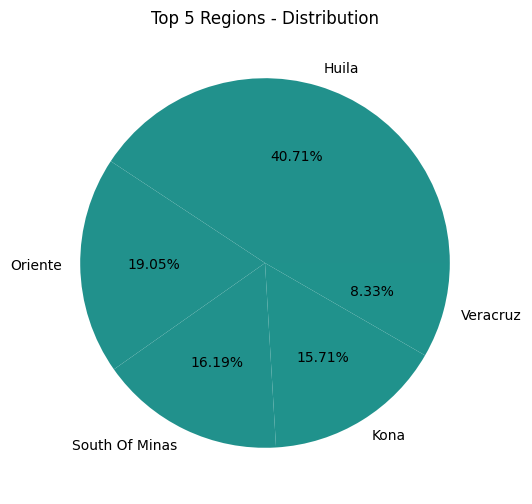

In [73]:
plt.figure(figsize=(6, 6))
colors = cm.viridis(np.linspace(0.5, 1, len(data.index)))
plt.pie(x=data['count'][:5], labels=data['Region'][:5], autopct='%1.2f%%',colors=colors)
plt.title("Top 5 Regions - Distribution")
plt.show()

In [74]:
df.head()

,Species,Owner,Country_of_Origin,Mill,Company,Region,Producer,Number_of_Bags,Bag_Weight,In_Country_Partner,Harvest_Year,Grading_Date,Variety,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean_Cup,Sweetness,Cupper_Points,Total_Cup_Points,Moisture,Category_One_Defects,Quakers,Color,Category_Two_Defects,Expiration,Certification_Body,Altitude_Clean,Weight_Kg_Clean,Processing_Method_Clean
0,Arabica,Metad Plc,Ethiopia,Metad Plc,metad agricultural developmet plc,Guji-Hambela,METAD PLC,300.0,60 kg,METAD Agricultural Development plc,2014,2015-04-04,Caturra,8.67,8.83,8.67,8.75,8.50,8.42,10.0,10.0,10.0,8.75,90.58,0.12,0,0.0,Green,0,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed
1,Arabica,Metad Plc,Ethiopia,Metad Plc,metad agricultural developmet plc,Guji-Hambela,METAD PLC,300.0,60 kg,METAD Agricultural Development plc,2014,2015-04-04,Other,8.75,8.67,8.50,8.58,8.42,8.42,10.0,10.0,10.0,8.58,89.92,0.12,0,0.0,Green,1,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed
2,Arabica,Grounds For Health Admin,Guatemala,Beneficio Ixchel,nan,Huila,La Plata,5.0,1,Specialty Coffee Association,2012,2010-05-31,Bourbon,8.42,8.50,8.42,8.42,8.33,8.42,10.0,10.0,10.0,9.25,89.75,0.00,0,0.0,Green,0,2011-05-31,Specialty Coffee Association,1600.0,1.0,Washed
3,Arabica,Yidnekachew Dabessa,Ethiopia,Wolensu,yidnekachew debessa coffee plantation,Oromia,Yidnekachew Dabessa Coffee Plantation,320.0,60 kg,METAD Agricultural Development plc,2014,2015-03-26,Caturra,8.17,8.58,8.42,8.42,8.50,8.25,10.0,10.0,10.0,8.67,89.00,0.11,0,0.0,Green,2,2016-03-25,METAD Agricultural Development plc,1800.0,60.0,Dry
4,Arabica,Metad Plc,Ethiopia,Metad Plc,metad agricultural developmet plc,Guji-Hambela,METAD PLC,300.0,60 kg,METAD Agricultural Development plc,2014,2015-04-04,Other,8.25,8.50,8.25,8.50,8.42,8.33,10.0,10.0,10.0,8.58,88.83,0.12,0,0.0,Green,2,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed


In [75]:
df['Total_Tonnes'] = df['Weight_Kg_Clean']* df['Number_of_Bags']/1000
df.drop(columns='Bag_Weight',inplace=True)
df.head()

,Species,Owner,Country_of_Origin,Mill,Company,Region,Producer,Number_of_Bags,In_Country_Partner,Harvest_Year,Grading_Date,Variety,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean_Cup,Sweetness,Cupper_Points,Total_Cup_Points,Moisture,Category_One_Defects,Quakers,Color,Category_Two_Defects,Expiration,Certification_Body,Altitude_Clean,Weight_Kg_Clean,Processing_Method_Clean,Total_Tonnes
0,Arabica,Metad Plc,Ethiopia,Metad Plc,metad agricultural developmet plc,Guji-Hambela,METAD PLC,300.0,METAD Agricultural Development plc,2014,2015-04-04,Caturra,8.67,8.83,8.67,8.75,8.50,8.42,10.0,10.0,10.0,8.75,90.58,0.12,0,0.0,Green,0,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed,18.000
1,Arabica,Metad Plc,Ethiopia,Metad Plc,metad agricultural developmet plc,Guji-Hambela,METAD PLC,300.0,METAD Agricultural Development plc,2014,2015-04-04,Other,8.75,8.67,8.50,8.58,8.42,8.42,10.0,10.0,10.0,8.58,89.92,0.12,0,0.0,Green,1,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed,18.000
2,Arabica,Grounds For Health Admin,Guatemala,Beneficio Ixchel,nan,Huila,La Plata,5.0,Specialty Coffee Association,2012,2010-05-31,Bourbon,8.42,8.50,8.42,8.42,8.33,8.42,10.0,10.0,10.0,9.25,89.75,0.00,0,0.0,Green,0,2011-05-31,Specialty Coffee Association,1600.0,1.0,Washed,0.005
3,Arabica,Yidnekachew Dabessa,Ethiopia,Wolensu,yidnekachew debessa coffee plantation,Oromia,Yidnekachew Dabessa Coffee Plantation,320.0,METAD Agricultural Development plc,2014,2015-03-26,Caturra,8.17,8.58,8.42,8.42,8.50,8.25,10.0,10.0,10.0,8.67,89.00,0.11,0,0.0,Green,2,2016-03-25,METAD Agricultural Development plc,1800.0,60.0,Dry,19.200
4,Arabica,Metad Plc,Ethiopia,Metad Plc,metad agricultural developmet plc,Guji-Hambela,METAD PLC,300.0,METAD Agricultural Development plc,2014,2015-04-04,Other,8.25,8.50,8.25,8.50,8.42,8.33,10.0,10.0,10.0,8.58,88.83,0.12,0,0.0,Green,2,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed,18.000


In [76]:
print('Total tonnes of Coffee produced',np.round(df['Total_Tonnes'].sum(),2),'Tons')

Total tonnes of Coffee produced 58006.12 Tons


In [77]:
df.drop(columns=['Company','Producer'],inplace=True)

In [78]:
data = df['In_Country_Partner'].value_counts().reset_index()
data

,In_Country_Partner,count
0,Specialty Coffee Association,313
1,AMECAFE,205
2,Almacafé,178
3,Asociacion Nacional Del Café,155
4,Brazil Specialty Coffee Association,67
5,Instituto Hondureño del Café,60
6,Blossom Valley International,58
7,Africa Fine Coffee Association,49
8,Specialty Coffee Association of Costa Rica,42
9,NUCOFFEE,36


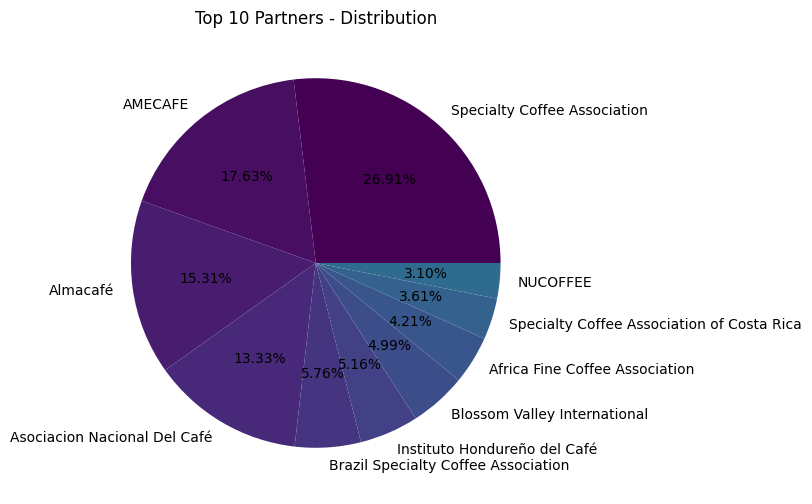

In [79]:

plt.figure(figsize=(6, 6))


colors = cm.viridis(np.linspace(0, 1, len(data.index)))
plt.pie(x=data['count'][:10], labels=data['In_Country_Partner'][:10], autopct='%1.2f%%',colors=colors)
plt.title("Top 10 Partners - Distribution")
plt.show()

In [80]:
df.tail()

,Species,Owner,Country_of_Origin,Mill,Region,Number_of_Bags,In_Country_Partner,Harvest_Year,Grading_Date,Variety,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean_Cup,Sweetness,Cupper_Points,Total_Cup_Points,Moisture,Category_One_Defects,Quakers,Color,Category_Two_Defects,Expiration,Certification_Body,Altitude_Clean,Weight_Kg_Clean,Processing_Method_Clean,Total_Tonnes
1334,Robusta,Luis Robles,Ecuador,Our Own Lab,"San Juan, Playas",1.0,Specialty Coffee Association,2016,2016-01-19,Caturra,7.75,7.58,7.33,7.58,5.08,7.83,10.00,10.00,7.75,7.83,78.75,0.00,0,0.0,Green,1,2017-01-18,Specialty Coffee Association,1100.0,2.00,Washed,0.00200
1335,Robusta,Luis Robles,Ecuador,Own Laboratory,"San Juan, Playas",1.0,Specialty Coffee Association,2016,2016-01-19,Caturra,7.50,7.67,7.75,7.75,5.17,5.25,10.00,10.00,8.42,8.58,78.08,0.00,0,0.0,Bluish/Blue-Green,0,2017-01-18,Specialty Coffee Association,NaN,2.00,Washed,0.00200
1336,Robusta,James Moore,United States,Cafe Cazengo,"Kwanza Norte Province, Angola",1.0,Specialty Coffee Association,2014,2014-12-23,Caturra,7.33,7.33,7.17,7.42,7.50,7.17,9.33,9.33,7.42,7.17,77.17,0.00,0,0.0,Green,6,2015-12-23,Specialty Coffee Association,795.0,1.00,Dry,0.00100
1337,Robusta,Cafe Politico,India,Beneficio Ixchel,Huila,1.0,Specialty Coffee Association,2013,2014-08-25,Caturra,7.42,6.83,6.75,7.17,7.25,7.00,9.33,9.33,7.08,6.92,75.08,0.10,20,0.0,Green,1,2015-08-25,Specialty Coffee Association,1100.0,2.27,Dry,0.00227
1338,Robusta,Cafe Politico,Vietnam,Beneficio Ixchel,Huila,1.0,Specialty Coffee Association,2013,2014-08-25,Caturra,6.75,6.67,6.50,6.83,6.92,6.83,9.33,9.33,6.67,7.92,73.75,0.12,63,0.0,Green,9,2015-08-25,Specialty Coffee Association,1100.0,2.27,Dry,0.00227


In [81]:
df.drop('In_Country_Partner',axis=1,inplace=True)

In [82]:
df.head()

,Species,Owner,Country_of_Origin,Mill,Region,Number_of_Bags,Harvest_Year,Grading_Date,Variety,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean_Cup,Sweetness,Cupper_Points,Total_Cup_Points,Moisture,Category_One_Defects,Quakers,Color,Category_Two_Defects,Expiration,Certification_Body,Altitude_Clean,Weight_Kg_Clean,Processing_Method_Clean,Total_Tonnes
0,Arabica,Metad Plc,Ethiopia,Metad Plc,Guji-Hambela,300.0,2014,2015-04-04,Caturra,8.67,8.83,8.67,8.75,8.50,8.42,10.0,10.0,10.0,8.75,90.58,0.12,0,0.0,Green,0,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed,18.000
1,Arabica,Metad Plc,Ethiopia,Metad Plc,Guji-Hambela,300.0,2014,2015-04-04,Other,8.75,8.67,8.50,8.58,8.42,8.42,10.0,10.0,10.0,8.58,89.92,0.12,0,0.0,Green,1,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed,18.000
2,Arabica,Grounds For Health Admin,Guatemala,Beneficio Ixchel,Huila,5.0,2012,2010-05-31,Bourbon,8.42,8.50,8.42,8.42,8.33,8.42,10.0,10.0,10.0,9.25,89.75,0.00,0,0.0,Green,0,2011-05-31,Specialty Coffee Association,1600.0,1.0,Washed,0.005
3,Arabica,Yidnekachew Dabessa,Ethiopia,Wolensu,Oromia,320.0,2014,2015-03-26,Caturra,8.17,8.58,8.42,8.42,8.50,8.25,10.0,10.0,10.0,8.67,89.00,0.11,0,0.0,Green,2,2016-03-25,METAD Agricultural Development plc,1800.0,60.0,Dry,19.200
4,Arabica,Metad Plc,Ethiopia,Metad Plc,Guji-Hambela,300.0,2014,2015-04-04,Other,8.25,8.50,8.25,8.50,8.42,8.33,10.0,10.0,10.0,8.58,88.83,0.12,0,0.0,Green,2,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed,18.000


In [83]:
df['Country_of_Origin'].isnull().sum()

np.int64(0)

In [84]:
import pandas as pd
import plotly.express as px

coffee_countries = df['Country_of_Origin'].unique().tolist()

highlight_df = pd.DataFrame({
    'Country': coffee_countries,
    'Coffee_Origin': 1 
})

fig = px.choropleth(
    highlight_df,
    locations='Country',
    locationmode='country names',
    color='Coffee_Origin',
    color_continuous_scale=['#f0f0f0', '#440154'],  
    title='Coffee Origin Countries'
)

fig.update_coloraxes(showscale=False)  
fig.update_layout(geo=dict(showframe=False, projection_type='natural earth'))
fig.show()


In [85]:
df.head()

,Species,Owner,Country_of_Origin,Mill,Region,Number_of_Bags,Harvest_Year,Grading_Date,Variety,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean_Cup,Sweetness,Cupper_Points,Total_Cup_Points,Moisture,Category_One_Defects,Quakers,Color,Category_Two_Defects,Expiration,Certification_Body,Altitude_Clean,Weight_Kg_Clean,Processing_Method_Clean,Total_Tonnes
0,Arabica,Metad Plc,Ethiopia,Metad Plc,Guji-Hambela,300.0,2014,2015-04-04,Caturra,8.67,8.83,8.67,8.75,8.50,8.42,10.0,10.0,10.0,8.75,90.58,0.12,0,0.0,Green,0,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed,18.000
1,Arabica,Metad Plc,Ethiopia,Metad Plc,Guji-Hambela,300.0,2014,2015-04-04,Other,8.75,8.67,8.50,8.58,8.42,8.42,10.0,10.0,10.0,8.58,89.92,0.12,0,0.0,Green,1,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed,18.000
2,Arabica,Grounds For Health Admin,Guatemala,Beneficio Ixchel,Huila,5.0,2012,2010-05-31,Bourbon,8.42,8.50,8.42,8.42,8.33,8.42,10.0,10.0,10.0,9.25,89.75,0.00,0,0.0,Green,0,2011-05-31,Specialty Coffee Association,1600.0,1.0,Washed,0.005
3,Arabica,Yidnekachew Dabessa,Ethiopia,Wolensu,Oromia,320.0,2014,2015-03-26,Caturra,8.17,8.58,8.42,8.42,8.50,8.25,10.0,10.0,10.0,8.67,89.00,0.11,0,0.0,Green,2,2016-03-25,METAD Agricultural Development plc,1800.0,60.0,Dry,19.200
4,Arabica,Metad Plc,Ethiopia,Metad Plc,Guji-Hambela,300.0,2014,2015-04-04,Other,8.25,8.50,8.25,8.50,8.42,8.33,10.0,10.0,10.0,8.58,88.83,0.12,0,0.0,Green,2,2016-04-03,METAD Agricultural Development plc,1950.0,60.0,Washed,18.000


In [86]:
df.to_csv('/Users/swerve/Desktop/Projects /PYTHON/Reinforcement Project - Python/Coffee Quality Dataset/CoffeeClean.csv', index=False)

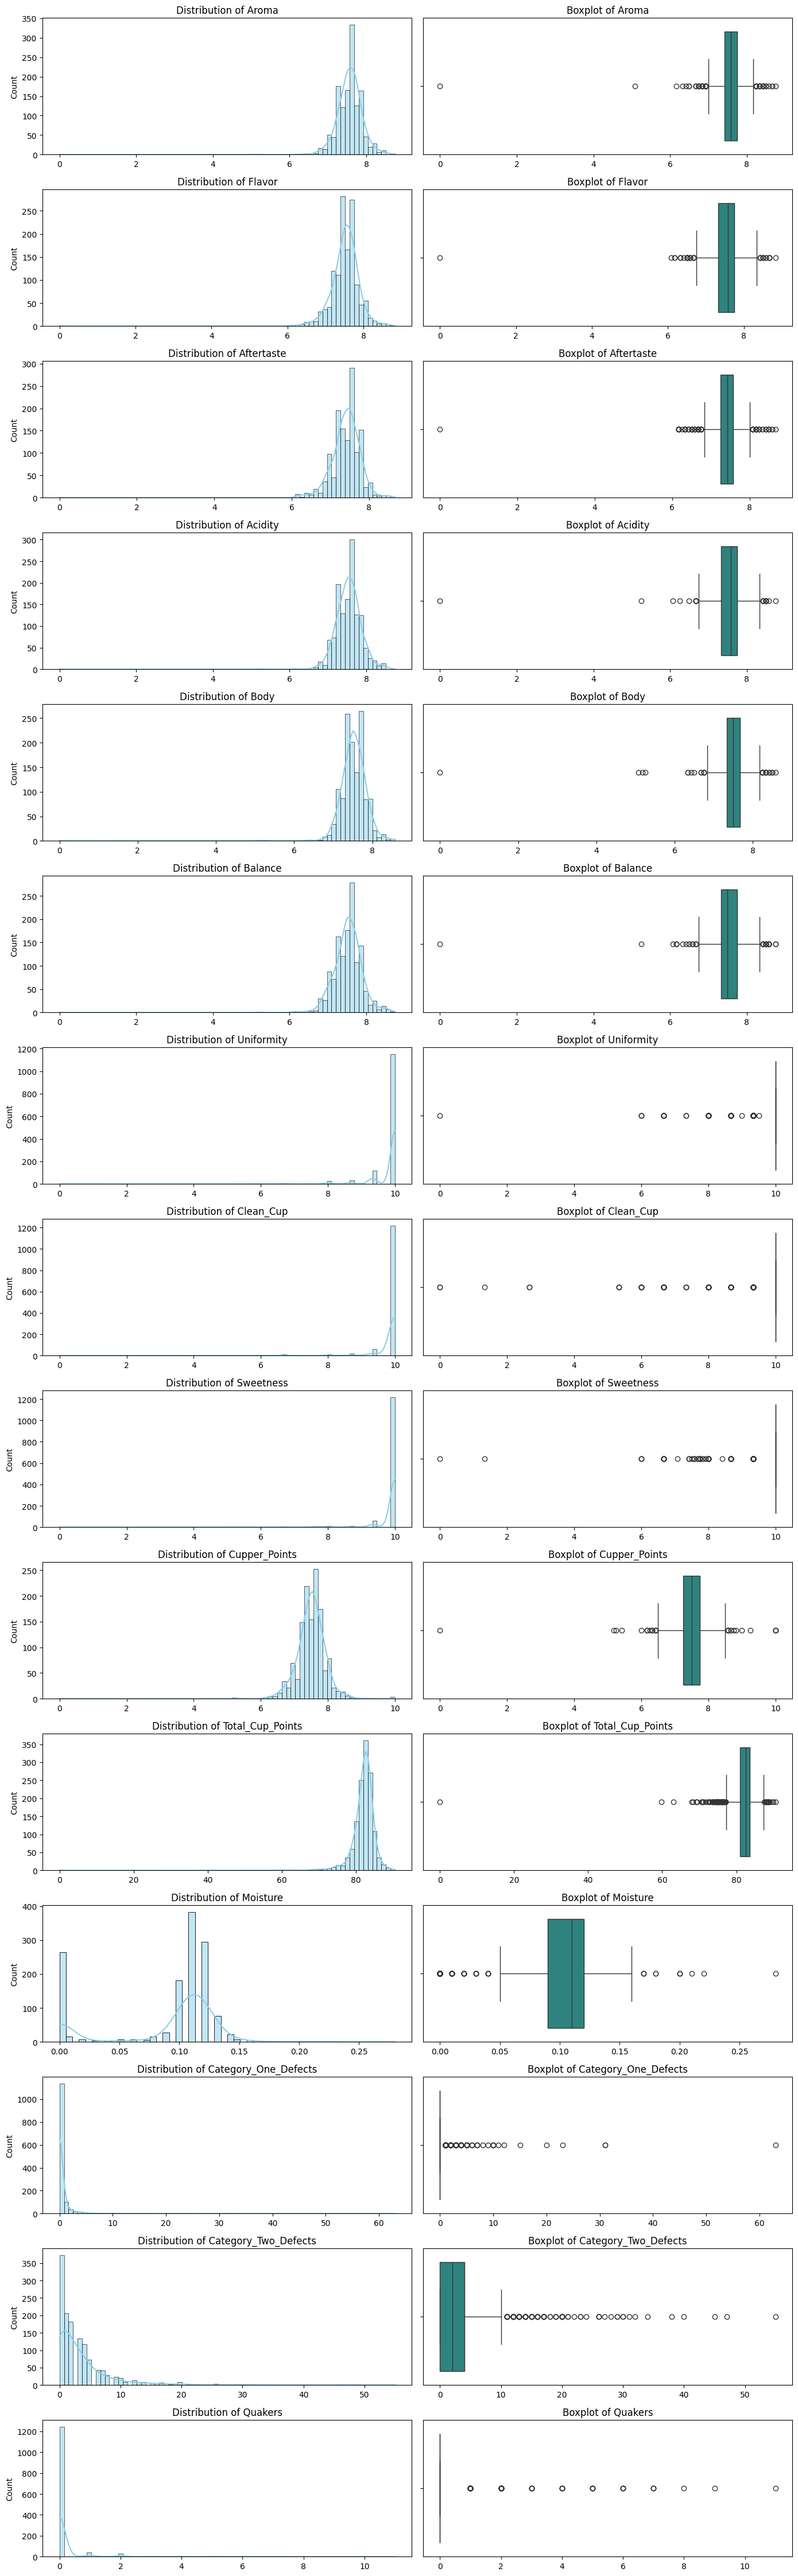

In [87]:
numerical_columns = [
    'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance',
    'Uniformity', 'Clean_Cup', 'Sweetness', 'Cupper_Points',
    'Total_Cup_Points', 'Moisture', 'Category_One_Defects',
    'Category_Two_Defects', 'Quakers'
]

# Plot histograms and boxplots
fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=2, figsize=(14, len(numerical_columns) * 3))

for i, col in enumerate(numerical_columns):
    # Histogram with KDE
    sns.histplot(df[col], kde=True, ax=axes[i][0], color='skyblue', palette='viridis')
    axes[i][0].set_title(f'Distribution of {col}')
    axes[i][0].set_xlabel('')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i][1], color='lightgreen', palette='viridis')
    axes[i][1].set_title(f'Boxplot of {col}')
    axes[i][1].set_xlabel('')

plt.tight_layout()
plt.show()


## Observations:
### Quality Scores (Aroma, Flavor, Aftertaste, etc.):

### Mostly centered around 7–8.

### Very few outliers, except Aroma which had an extreme value (~200), clearly an outlier.

### Defects (Category_One_Defects, Category_Two_Defects, Quakers):

### Highly skewed right — most coffees have 0–5 defects.

### Moisture:

### Mostly around 10–12%, but a few values near zero or below 6 may be problematic.

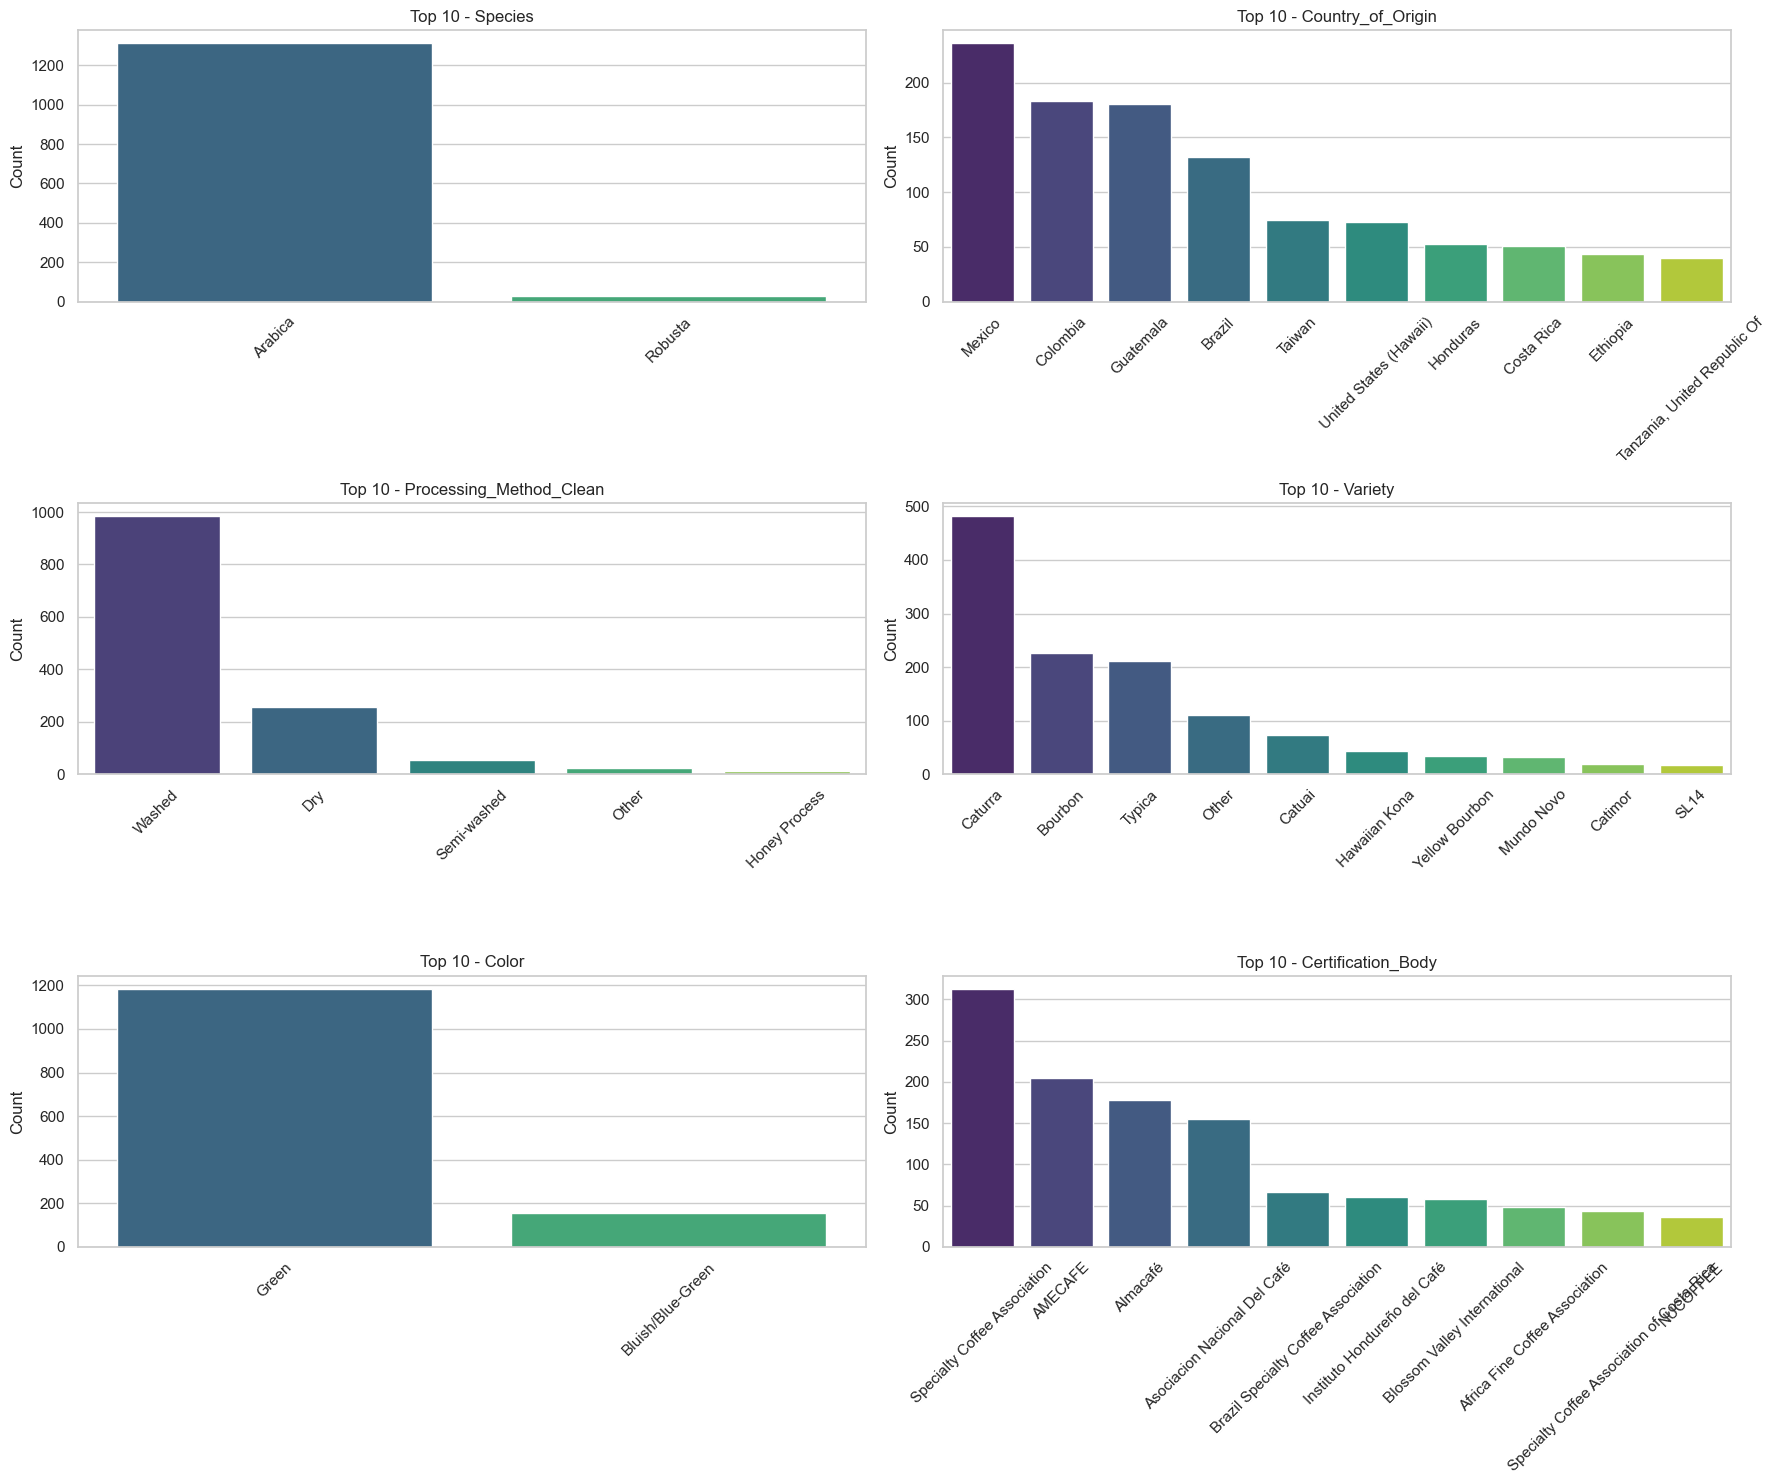

In [88]:
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

categorical_columns = [
    'Species',
    'Country_of_Origin',
    'Processing_Method_Clean',
    'Variety',
    'Color',
    'Certification_Body'
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index[:10], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top 10 - {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Observations

### Species: Dominated by Arabica

### Country_of_Origin: Mexico, Colombia, and Guatemala are top producers

### Processing_Method_Clean: Washed is by far the most common

### Variety: Caturra leads, followed by Bourbon and Typica

### Color: Almost all are Green

### Certification_Body: Specialty Coffee Association appears most frequently

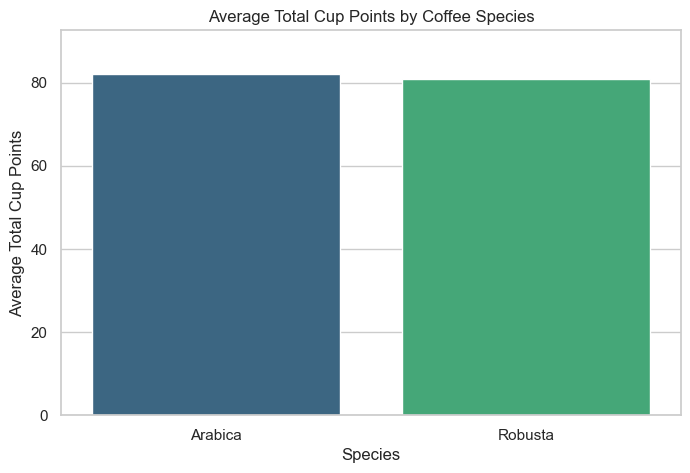

In [89]:
species_scores = df.groupby('Species')['Total_Cup_Points'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=species_scores, x='Species', y='Total_Cup_Points',  palette='viridis')
plt.title('Average Total Cup Points by Coffee Species')
plt.ylabel('Average Total Cup Points')
plt.xlabel('Species')
plt.ylim(0, df['Total_Cup_Points'].max() + 2)
plt.show()

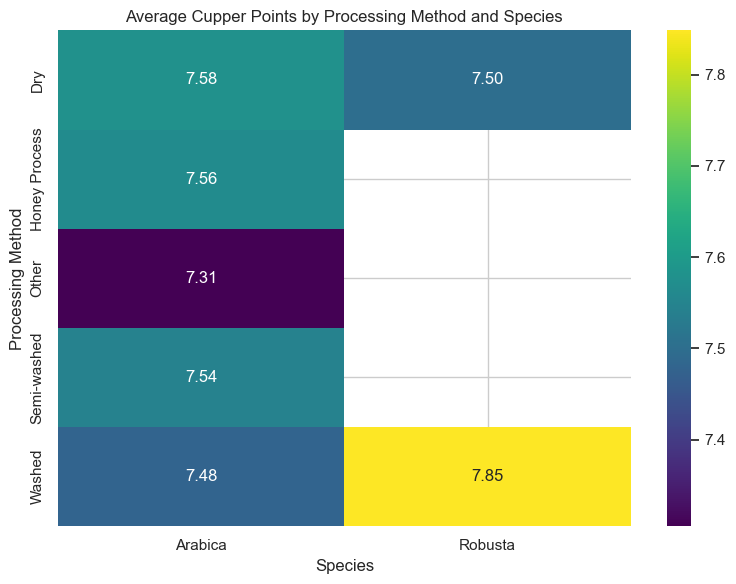

In [90]:
pivot_table = df.pivot_table(values='Cupper_Points', 
                              index='Processing_Method_Clean', 
                              columns='Species', 
                              aggfunc='mean')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt=".2f")
plt.title('Average Cupper Points by Processing Method and Species')
plt.ylabel('Processing Method')
plt.xlabel('Species')
plt.tight_layout()
plt.show()


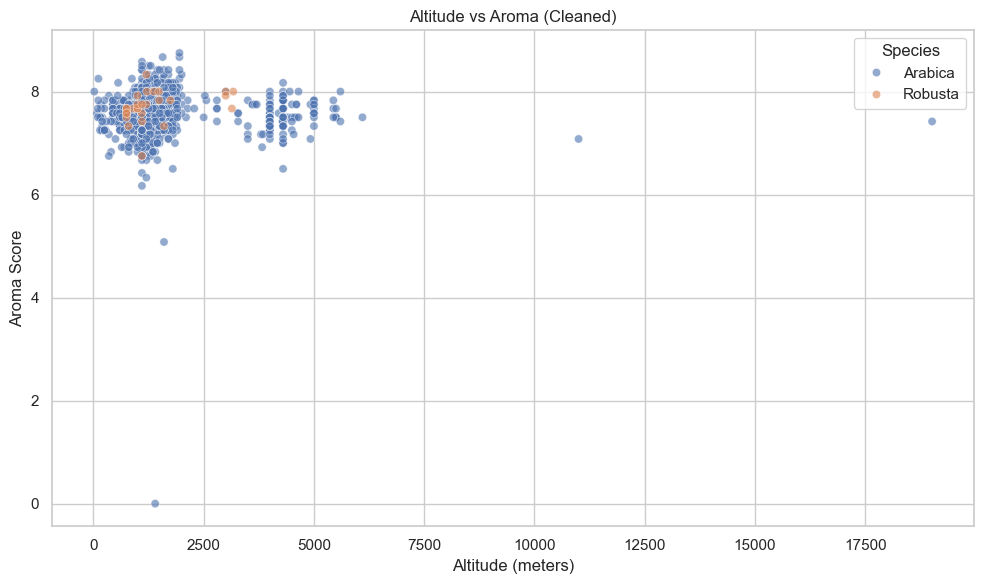

In [91]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Altitude_Clean', y='Aroma', hue='Species', alpha=0.6)
plt.title('Altitude vs Aroma (Cleaned)')
plt.xlabel('Altitude (meters)')
plt.ylabel('Aroma Score')
plt.grid(True)
plt.tight_layout()
plt.show()


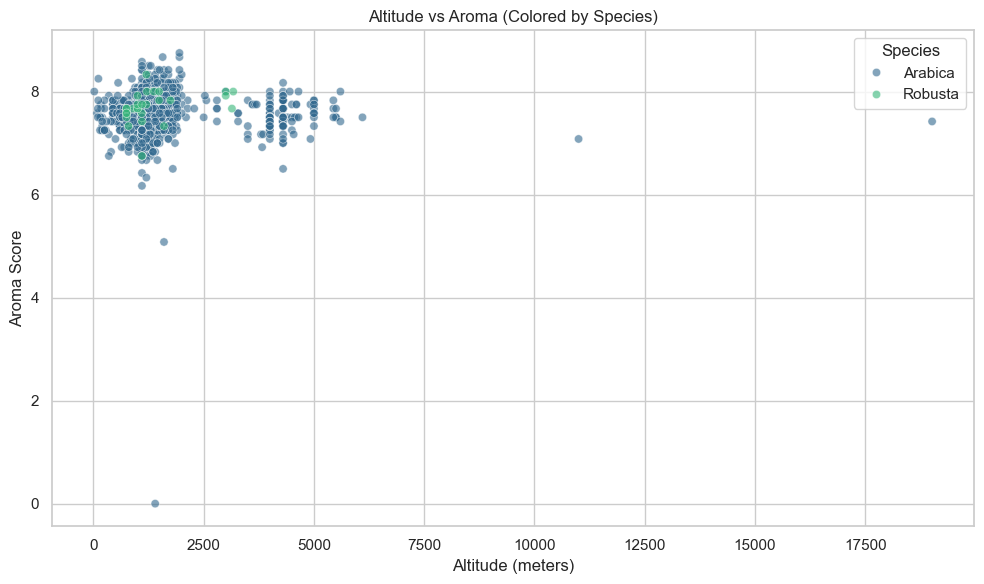

In [92]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Altitude_Clean', y='Aroma', hue='Species', alpha=0.6, palette='viridis')

plt.title('Altitude vs Aroma (Colored by Species)')
plt.xlabel('Altitude (meters)')
plt.ylabel('Aroma Score')
plt.legend(title='Species')
plt.grid(True)
plt.tight_layout()
plt.show()

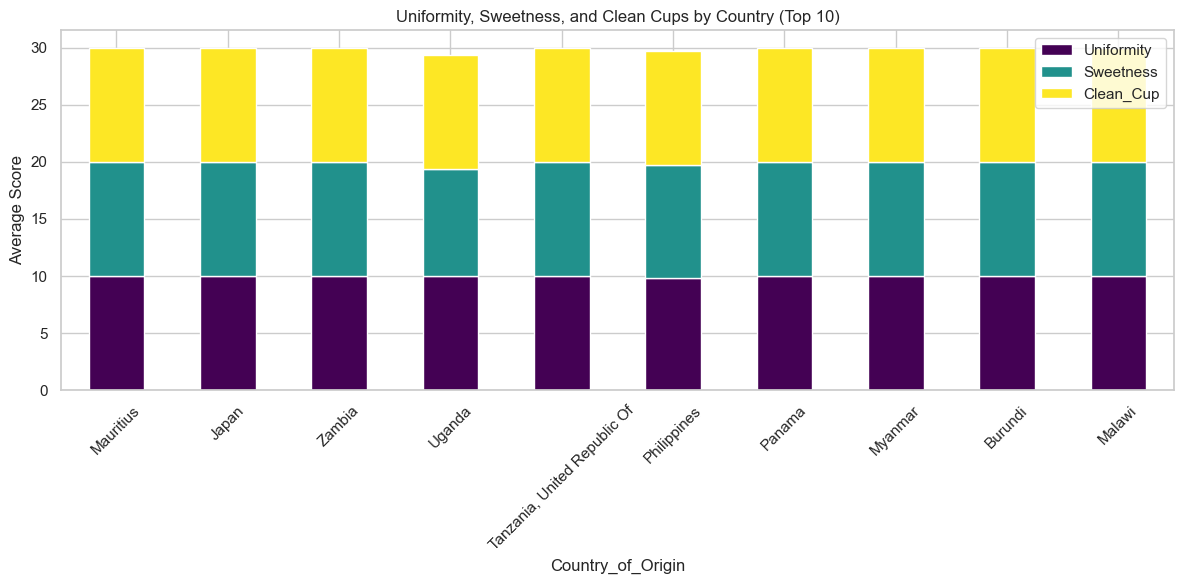

In [93]:
stack_metrics = ['Uniformity', 'Sweetness', 'Clean_Cup']

country_grouped = df.groupby('Country_of_Origin')[stack_metrics].mean().sort_values(by='Clean_Cup', ascending=False).head(10)

country_grouped.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Uniformity, Sweetness, and Clean Cups by Country (Top 10)')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


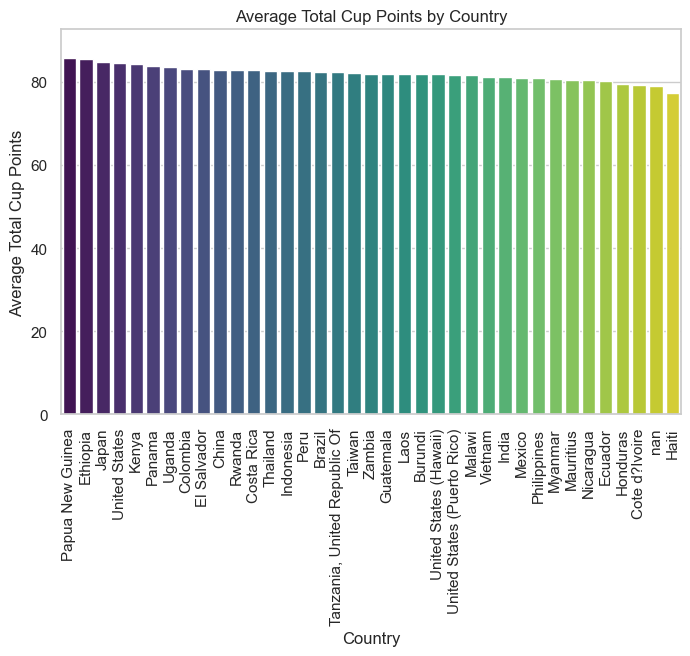

In [94]:
country_scores = df.groupby('Country_of_Origin')['Total_Cup_Points'].mean().sort_values(ascending=False).reset_index()
top_countries = country_scores.head(15)

plt.figure(figsize=(8, 5))
sns.barplot(data=country_scores, x='Country_of_Origin', y='Total_Cup_Points',  palette='viridis')
plt.title('Average Total Cup Points by Country')
plt.ylabel('Average Total Cup Points')
plt.xlabel('Country')
plt.xticks(rotation=90)
plt.ylim(0, df['Total_Cup_Points'].max() + 2)
plt.show()

### Scenario 1: Is the average total cup score different between Arabica and Robusta beans?
Goal: Test if there's a significant difference in mean cup score between Arabica and Robusta.


Species (categorical: Arabica / Robusta)
Total_Cup_Points (numerical)


H₀ (Null Hypothesis):
Mean Total_Cup_Points is equal for Arabica and Robusta beans.

𝐻0:
𝜇 Arabica = 𝜇 Robusta
 
H1 (Alternative Hypothesis):
Mean Total_Cup_Points is not equal for Arabica and Robusta.

𝐻1:
𝜇 Arabica ≠ 𝜇 Robusta

In [95]:
from scipy.stats import ttest_ind

arabica = df[df['Species'] == 'Arabica']['Total_Cup_Points']
robusta = df[df['Species'] == 'Robusta']['Total_Cup_Points']

ttest, p_value = ttest_ind(arabica, robusta, equal_var=False)

print("Hypothesis Test: Arabica vs Robusta \n")
print(f"T-Test Statistic = {ttest:.4f}")
print(f"p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: Significant difference in Total Cup Points between Arabica and Robusta.")
else:
    print("Failed to Reject H0: No significant difference in Total Cup Points between Arabica and Robusta.")

Hypothesis Test: Arabica vs Robusta 

T-Test Statistic = 2.6450
p-value = 0.0130
Reject H0: Significant difference in Total Cup Points between Arabica and Robusta.


### Scenario 2: Is the average total cup score different between different varieties?
Goal:
Test if there's a significant difference in mean cup score between Varieties.


Variety (categorical: Caturra/Bourbon/Typica/other etc)
Total_Cup_Points (numerical)


H₀ (Null Hypothesis):
Mean Total_Cup_Points is equal for all varieties.

𝐻0:
𝜇 Bourbon = 𝜇 Typica = 𝜇 Caturra

H1 (Alternative Hypothesis):
Mean Total_Cup_Points is not equal for different Varieties.

𝐻1:
𝜇 Bourbon ≠ 𝜇 Typica ≠ 𝜇 Caturra ≠ ...

In [96]:
from scipy.stats import f_oneway

top_varieties = df['Variety'].value_counts()
selected_varieties = top_varieties[top_varieties >= 30].index
filtered_df = df[df['Variety'].isin(selected_varieties)]

grouped_scores = [group['Total_Cup_Points'].values for name, group in filtered_df.groupby('Variety')]

f_stat, p_value = f_oneway(*grouped_scores)

print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: At least one variety has a significantly different mean Total Cup Points.")
else:
    print("Fail to Reject H0: No significant difference in mean Total Cup Points among the varieties.")


F-statistic: 4.4771, p-value: 0.0001
Reject H0: At least one variety has a significantly different mean Total Cup Points.


In [97]:
df.columns

Index(['Species', 'Owner', 'Country_of_Origin', 'Mill', 'Region',
       'Number_of_Bags', 'Harvest_Year', 'Grading_Date', 'Variety', 'Aroma',
       'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity',
       'Clean_Cup', 'Sweetness', 'Cupper_Points', 'Total_Cup_Points',
       'Moisture', 'Category_One_Defects', 'Quakers', 'Color',
       'Category_Two_Defects', 'Expiration', 'Certification_Body',
       'Altitude_Clean', 'Weight_Kg_Clean', 'Processing_Method_Clean',
       'Total_Tonnes'],
      dtype='object')